# Backmixing in tubular reactors

In [1]:
#IMPORT SECTION
import numpy as np
import scipy.integrate as integ #important for initial value problem
from scipy.integrate import solve_bvp #important for boundary value problem
import matplotlib.pyplot as plt #figures

## Background



### Residence time distribution

Plug-flow tubular reactors (PFR, PFTR) are ideal reactors, which differ to real reactors, since viscous forces will influence the flow. In laminar flow, for instance, a parabolic velocity profile of the fluid is formed, which can be described by the following equation:
$$
u(r) = 2 \bar{u} \left[ 1- \left( \frac{r}{R} \right)^2 \right] 
$$
with $u$ and $\bar{u}$ beeing the velocity and the mean velocity and $r$ beeing the radial position and $R$ the radius of the pipe.

Therefore, the cumulative distribution function $F(t)$, which describes the proportion of the fluid elements that have already left the balance volume, is not just a step function, which is assumed in a plug flow reactor. For a PFR, the function $F(t)$ can be written as:
$$
F(t) = H(t) =\left\{\begin{array}{ll} 1, & t > \tau \\
         0, & t < \tau \end{array}\right.
$$
with $\tau$ beeing the residence time and $H(t)$ beeing the Heaviside step function. The function expresses the residence time of a PFR with an instant increase at the mean residence time, meaning, that all fluid elements are leaving the reactor exactly at the same time.

For the laminar flow, the outer layer of fluid is moving slower than the inner part. The residence time is therefore distributed and can be expressed by:
$$
F(t) = 1-\frac{1}{4} \left(\frac{\bar{t}}{t}\right)^2
$$
where $\bar{t}$ is the mean residence time ($\bar{t}=L / \bar{u}=\bar{\tau}$).


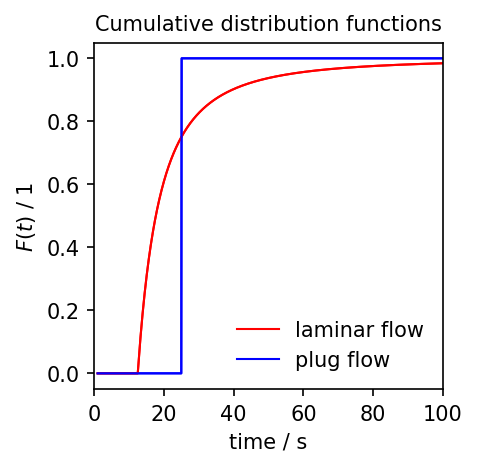

In [2]:
t = np.linspace(1,100,1000) # time in s
t_bar = 25 #mean residence time in s

# Calculating F(t) for laminar flow
F_lam = 1-0.25*(t_bar/t)**2
# Replacing all values below 0
F_lam = np.where(F_lam<0, 0, F_lam)

# Calculating F(t) for plug flow
F_plug = np.where(t<25,0,t)
F_plug = np.where(F_plug>25,1,F_plug)

# Setting the figure size and resolution
fig = plt.figure(figsize=(3, 3), dpi=150)

# Setting the color, linewidth, and linestyle
plt.plot(t, F_lam, color="red",  linewidth=1.0, linestyle="-")
plt.plot(t, F_plug, color="blue",  linewidth=1.0, linestyle="-")

# Setting the boundaries of the figure
plt.xlim(0, t.max())
plt.ylim(-0.05, 1.05)

# Use Latex to set tick labels
plt.xticks(fontsize=10, rotation=0)
plt.yticks(fontsize=10, rotation=0)

# 
plt.xlabel('time / s',fontsize=10)
plt.ylabel('$F(t)$ / 1',fontsize=10)
plt.title('Cumulative distribution functions',fontsize=10)

# Adding legends
plt.plot(t, F_lam, color="red",  linewidth=1.0, linestyle="-", label="laminar flow")
plt.plot(t, F_plug, color="blue",  linewidth=1.0, linestyle="-", label="plug flow")
plt.legend(loc='lower right', prop={'size': 10}, frameon=False)

plt.show() # show figure

## Backmixing models for PFR

For further information see:

[1] https://doi.org/10.1021/ie071635a

[2] https://doi.org/10.1016/0009-2509(53)80001-1


### Dispersion model

The cumulative distribution function has a very sharp increase in case of the ideal reactor. However, some fluid elements might have a slightly higher or lower residence time in reality. In this case, the curve would degenerate from a step function to a continuous function. Or in other words, in reality there will be some sort of backmixing. Therefore, residence time distribution models are typically located in the field of real reactors or non-ideal reactors.

The dispersion model assumes an additional term, which is superimposed to the convective mass balance in a PFR. The superimposed mechanism is comparable to a diffusive mass transfer. The additional parameter $\mathcal{D}$ is the dispersion coefficient, which is representing the strength of backmixing inside the reactor.
$$
u \frac{\text{d}c_i}{\text{d}z} = \mathcal{D} \frac{\text{d}^2 c_i }{\text{d} z^2} + \sum_{j=1}^{M} \nu_{i,j} r_j
$$

The dispersion coefficient can be expressed by a dimensionless number, which is the *Bodenstein-*number $Bo$. This characteristic number compares the fluid velocity $u$ times the length of the reactor $L$ with the dispersion coefficient. Therefore, the characteristic backmixing can be related to the convective mass transfer.
$$
Bo = \frac{u \, L}{\mathcal{D}}
$$

The $Bo$-number can be used to express the residence time distribution $E(t)$, which is nothing but the differential representation of the cumulative distribution function $F(t)$. $E(t)$ is normalized, since $F(t)$ is always approaching 1, the integral of $\int_{-\infty}^{+\infty} E(\Theta)=1$, with $\Theta=t/\bar{t}$. See figure "residence time distributions for different $Bo$-numbers".

$$
E(\Theta) = \frac{1}{\sqrt{4\pi / Bo}} \text{exp} \left[-\frac{ \left(1-\Theta \right)^2}{4 / Bo} \right]
$$

<>:26: SyntaxWarning: invalid escape sequence '\T'
<>:27: SyntaxWarning: invalid escape sequence '\T'
<>:26: SyntaxWarning: invalid escape sequence '\T'
<>:27: SyntaxWarning: invalid escape sequence '\T'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9836\2353222932.py:26: SyntaxWarning: invalid escape sequence '\T'
  plt.xlabel('$\Theta$ / 1',fontsize=10)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9836\2353222932.py:27: SyntaxWarning: invalid escape sequence '\T'
  plt.ylabel('$E(\Theta)$ / s$^-1$',fontsize=10)


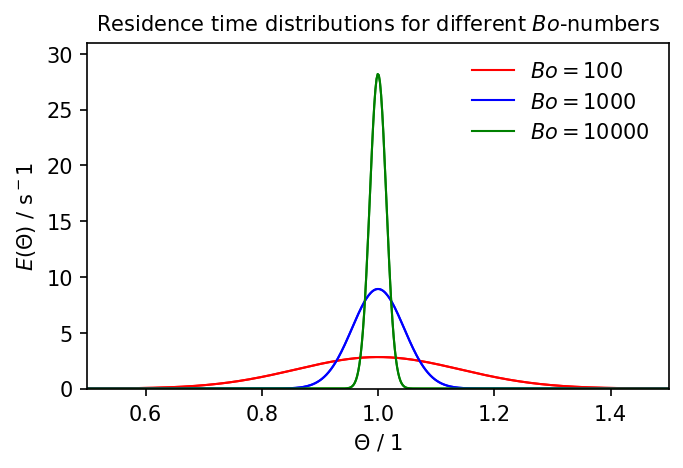

In [3]:
t = np.linspace(1,50,1000) # time in s
t_bar = 25 #mean residence time in s

# Calculating E(t) for different Bo
E_100 = (1/(4*np.pi/100)**0.5)*np.exp(-(1-(t/t_bar))**2/(4/100))
E_1000 = (1/(4*np.pi/1000)**0.5)*np.exp(-(1-(t/t_bar))**2/(4/1000))
E_10000 = (1/(4*np.pi/10000)**0.5)*np.exp(-(1-(t/t_bar))**2/(4/10000))

# Setting the figure size and resolution
fig = plt.figure(figsize=(5,3), dpi=150)

# Setting the color, linewidth, and linestyle
plt.plot(t/t_bar, E_100, color="red",  linewidth=1.0, linestyle="-")
plt.plot(t/t_bar, E_1000, color="blue",  linewidth=1.0, linestyle="-")
plt.plot(t/t_bar, E_10000, color="green",  linewidth=1.0, linestyle="-")

# Setting the boundaries of the figure
plt.xlim(0.5, 1.5)
plt.ylim(-0.05, E_10000.max()*1.1)

# Use Latex to set tick labels
plt.xticks(fontsize=10, rotation=0)
plt.yticks(fontsize=10, rotation=0)

# 
plt.xlabel('$\Theta$ / 1',fontsize=10)
plt.ylabel('$E(\Theta)$ / s$^-1$',fontsize=10)
plt.title('Residence time distributions for different $Bo$-numbers',fontsize=10)

# Adding legends
plt.plot(t/t_bar, E_100, color="red",  linewidth=1.0, linestyle="-", label="$Bo=100$")
plt.plot(t/t_bar, E_1000, color="blue",  linewidth=1.0, linestyle="-", label="$Bo=1000$")
plt.plot(t/t_bar, E_10000, color="green",  linewidth=1.0, linestyle="-", label="$Bo=10000$")
plt.legend(loc='upper right', prop={'size': 10}, frameon=False)

plt.show() # show figure

However, the application for reactors is quite complicated, since the second order differential equation requires an initial condition and two boundary conditions. The main problem arises from the backmixing at the reactor inlet, where the concentration is already backmixed with the reaction mixture downstream and upstream. Thus, the concentration of the reactant $i$ at the position $z=0$ is not the feed composition $c_{i0}$, but a value below. At the reactor outlet, the concentration cannot be predicted a priori, since the reaction extent is unknown. This boundary value problem was solved by **Danckwerts**, who derived the **Danckwerts**-boundary conditions (see [2]):
\begin{align}
z &= 0: \qquad & u_0 A_0 c_{i0} &= u A c_i -A\mathcal{D} \frac{\text{d} c_i}{\text{d} z}\\
z &= L: \qquad & \frac{\text{d} c_i}{\text{d} z} &= 0
\end{align}
Here, the upstream system is represented by the variables $u_0$, $A_0$ and $c_{i0}$ beeing the velocity the area and the concentration. Please note, the initial condition $c_{i0}$ is located upstream, which means outside of the observed system. The equation simplifies for constant areas and velocities.

The boundary condition at the reactor outlet is simplified to a gradient beeing zero, since there will be no reaction downstream of the reactor. Therefore, the concentration is forced to a flat profile at the reactor outlet. 

### Example for implementation

Let us assume a differential equation for mass transfer and reaction in a catalyst particle for different geometries in steady-state:
$$ 
\frac{\text{d}^2 c_\text{A}}{\text{d} x^2} = -\frac{a}{x} \frac{\text{d} c_\text{A}}{\text{d} x} + \frac{k_1}{D_{\text{A,eff}}} c_\text{A}
$$

and the boundary conditions

\begin{align}
x=0: \qquad & \frac{\text{d} c_\text{A}}{\text{d} x} = 0 \\
x=\chi: \qquad & \frac{\text{d} c_\text{A}}{\text{d} x} = -\frac{k_\text{A,fl}}{D_{\text{A,eff}}} \left(c_\text{A,x=L}-c_\text{A,bulk} \right)
\end{align}

The values are given with:

$D_{\text{A,eff}}= 1 \cdot 10^{-6} \,\mathrm{m}^2 \, \mathrm{s}^{-1}$
$k_1=100 \, \mathrm{s}^{-1}$
$k_\text{fl}=1 \, \mathrm{m} \, \mathrm{s}^{-1}$
$c_\text{A,bulk}=100 \, \mathrm{mol} \, \mathrm{m}^{-3}$
and
$\chi=0.01 \, \mathrm{m}$

The example can be implemented in the following way:

<>:71: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\c'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9836\1747273374.py:71: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("$\chi$ / m")


True True True
Number of itarations:  1 8 8


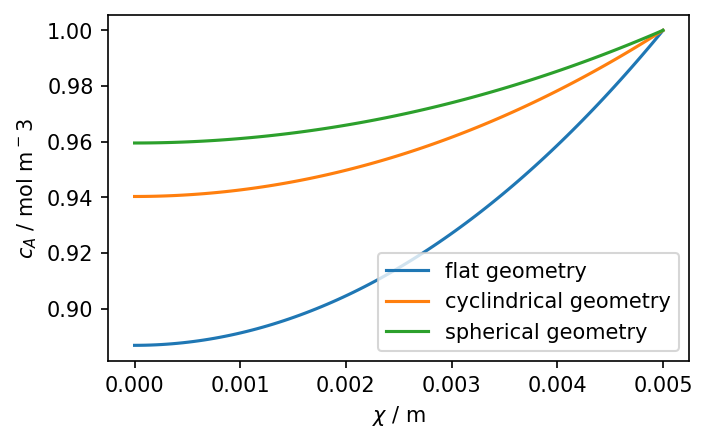

In [4]:
#Parameters
D_Aeff = 1E-6 # effective diffusion coefficient m^2/s
k_1 = 0.01 # reaction rate constant 1/s
k_fl = 1 # outer mass transfer coefficient m/s
c_Abulk = 1 # concentration in bulk mol/m^3
chi = 0.005 # spatial length of the catalyst m

#BVP-solver
def fun_bvp_flat(x, y):
  c_A = y[0] #transferring to local variable
  dc_Adx = y[1] #transferring to local variable
  x_a = x

  dydx = dc_Adx # y''
  d2ydx2 = (k_1/D_Aeff)*c_A -(0/(x_a))*y[1] #y'

  sol = np.vstack((dydx, d2ydx2)) #stack the results

  return sol #return solution

def fun_bvp_cylinder(x,y):
  c_A = y[0] #transferring to local variable
  dc_Adx = y[1] #transferring to local variable
  x_a = x

  dydx = dc_Adx # y''
  d2ydx2 = (k_1/D_Aeff)*c_A -(1/(x_a))*y[1] #y'

  sol = np.vstack((dydx, d2ydx2)) #stack the results

  return sol #return solution

def fun_bvp_sphere(x,y):
  c_A = y[0] #transferring to local variable
  dc_Adx = y[1] #transferring to local variable
  x_a = x

  dydx = dc_Adx # y''
  d2ydx2 = (k_1/D_Aeff)*c_A -(2/(x_a))*y[1] #y'

  sol = np.vstack((dydx, d2ydx2)) #stack the results

  return sol #return solution

#Boundary condition (bc)
def bc(ya, yb):
  bc_x0 = ya[1] #bc @ pos x=0 ya[1]=dc_Adx
  bc_xchi = yb[1] + k_fl/D_Aeff*(yb[0]-c_Abulk) #bc @ pos x=0.01m yb[0]=c_A and yb[1]=dc_Adx
  return np.array([ bc_x0, bc_xchi]) #return solution

x = np.linspace(chi/10000, chi, 100) #defining range. Please note, lower value is chi/10000, because x=0 is not possible
y_a_init = np.zeros((2, x.size))
y_a = y_a_init
#Call solver
sol_flat = solve_bvp(fun_bvp_flat, bc, x, y_a)
sol_cylinder = solve_bvp(fun_bvp_cylinder, bc, x, y_a)
sol_sphere = solve_bvp(fun_bvp_sphere, bc, x, y_a)

#Success of solver and number of iterations
print(sol_flat.success, sol_cylinder.success, sol_sphere.success) # solver successful
print('Number of itarations: ', sol_flat.niter, sol_cylinder.niter, sol_sphere.niter)

#Plot
# Setting the figure size and resolution
fig = plt.figure(figsize=(5,3), dpi=150)

plt.plot(sol_flat.x, sol_flat.y[0,:], label="flat geometry")
plt.plot(sol_cylinder.x, sol_cylinder.y[0,:], label="cyclindrical geometry")
plt.plot(sol_sphere.x, sol_sphere.y[0,:], label="spherical geometry")
plt.legend()
plt.xlabel("$\chi$ / m")
plt.ylabel("$c_A$ / mol m$^-3$")
plt.show()

## Tasks

The reactor is a tubular reactor with 10 m length and a diameter of 32 mm. The reactor is fed from an upstream section with a diameter of 150 mm with a gas. The volumetric flow rate is 1 $\textrm{L s}^{-1}$. The gas contains 100 $\textrm{mol m}^{-3}$ of component A, which is converted to a product B by a certain reaction order.

The topic shall be discussed with the following aspects:

1. Implement the boundary value problem and validate the result with an initial value problem.

2. Investigate the influence of the backmixing for changing dispersions.
    - Discuss theoretical and practical boundary cases.
    - Display the influence with reference to $Bo$-number.

3. Implement a CSTR-cascade and compare the results at three distinct points with the dispersion model.


**Hints**

* Assume a reaction order of 1 in first attempt.
* If you use different reaction orders, you will need a common reference for comparison.
* The dispersion is at least in the range of the diffusion coefficient but most probably above.

## Learning aims

The students are able to

* implement boundary value problems in a bvp-solver.

* apply backmixing models in a tubular reactors and use the dispersion model.

* compare simulation results to ideal reactors (CSTR, PFR).

* investigate the influence of backmixing on the reactor performance.

## Use of AI tools in this assignment

The use of AI tools (e.g. ChatGPT, Claude, Gemini, GitHub Copilot, Perplexity) is **explicitly permitted**, but must be reflected and documented. The full course methodology is provided in a separate handout; the points below summarise what applies to every assignment.

**Permissible:** code generation and debugging, verification strategies, concept explanation for self-study, identification of literature, language editing.

**Not permissible:** AI must not be used to provide the *intellectual structure of the argumentation* — i.e. the line of reasoning of the discussion, the derivation of conclusions, or the engineering judgement underlying design and operation decisions. AI use for text production is restricted to proof-reading and language polishing, once the substance has been formulated by you.

**You remain fully responsible** for correctness. Errors in AI outputs that you fail to detect — particularly in thermodynamic data, kinetic parameters, literature references and code — are attributed to you.

### Required documentation

Add a section **"AI use and reflection"** near the end of your report covering:

1. **Tools used** — name, model/version, date.
2. **Areas of use** — for which subtasks (research, code, debugging, verification, interpretation, language editing).
3. **Prompting strategy** — structure and logic of your prompting workflow for substantive use.
4. **Critical examination** — verification against authoritative sources, plausibility checks, unit consistency, errors detected and corrected.
5. **Statement of own contribution** — which parts of the scientific reasoning are your independent work.

**Mandatory appendix:** if AI has been used beyond purely linguistic editing, attach the verbatim chat protocol(s) as a separate PDF file alongside your main report.

### Grading

Grading is primarily based on subject-specific intellectual input, scientific depth and rigour. The AI documentation itself is enters to the assessment as follows:

* **Reflective documentation** of AI use is expected; incomplete documentation is treated as a deficiency in scientific rigour.
* **Critical engagement** with AI outputs (errors identified and corrected, independent validation) is credited positively.
* **Uncritical adoption** (fabricated references, unverified data, implausible results, superficial discussion) is reflected negatively, whether declared or not.
* **Undeclared** AI use is treated as undisclosed sources and may lead to failing the assignment.

In case of doubt, contact the course staff before submission — clarification before the deadline is always possible and welcome.
We also refer to the more extensive guideline to the use and documentation of AI tools, since we provide a minimal version here, only.